# Entrenamiento del modelo

In [1]:
import pandas as pd
from xgboost import XGBRegressor
import optuna
import numpy as np
import random
import matplotlib.pyplot as plt

# FIX R1 (reproducibilidad): semillas globales para que toda la corrida sea reproducible.
np.random.seed(42)
random.seed(42)

C:\Users\FERNANDO VEGA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargamos los datos preprocesados y listos para su uso

In [2]:
x_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
x_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')
x_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')
print(y_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11766 entries, 0 to 11765
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   target  11766 non-null  float64
dtypes: float64(1)
memory usage: 92.1 KB
None


In [3]:
cols_cat = ['CARACTER', 'ORIGEN', 'DEPARTAMENTO', 'MUNICIPIO']

# for col in cols_cat:
#     x_train[col] = x_train[col].astype('category')
#     x_test[col]   = x_val[col].astype('category')
#     x_val[col]  = x_test[col].astype('category')
# display(x_train.info())
for col in cols_cat:
    x_train[col] = x_train[col].astype('category')
    x_val[col]   = x_val[col].astype('category').cat.set_categories(x_train[col].cat.categories)
    x_test[col]  = x_test[col].astype('category').cat.set_categories(x_train[col].cat.categories)


In [4]:
modelo_baseline = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    eval_metric='rmse',
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical = True
)

modelo_baseline.fit(x_train,y_train,eval_set=[(x_val,y_val)],verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [5]:
display(y_val.head())

,target
0,4.58
1,11.07
2,7.59
3,7.67
4,6.20


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# FIX C1b: el baseline se evalua sobre VALIDACION (no sobre test), para que la
# comparacion baseline-vs-modelo (seleccionado por Optuna sobre val) sea justa,
# sobre el mismo conjunto. El test se reserva para la unica medicion final.
# Clip [0,100] consistente con el modelo final (dominio de una tasa de desercion).
y_pred_val = np.clip(modelo_baseline.predict(x_val), 0, 100)

rmse_base_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_base_val = mean_absolute_error(y_val, y_pred_val)

print(f"Baseline (validacion) — RMSE: {rmse_base_val:.2f} | MAE: {mae_base_val:.2f}")

Baseline (validacion) — RMSE: 5.22 | MAE: 2.75


Realiazamos etapa de Tunning del modelo XGboosting para ver si es mejor que el anterior usando la libreria Optuna, que es más eficiente y rápida que las busquedas de scikit learn, pero usa la técnica de bayesian grid. 

In [7]:

def objective(trial):
    params = {
        'objective':'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 42,
        'n_estimators': 1000,
        'enable_categorical': True,
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.4),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'early_stopping_rounds':50
    }

    modelo = XGBRegressor(**params)

    modelo.fit(
        x_train, y_train,
        eval_set=[(x_val, y_val)],
        verbose=False
    )

    # FIX C1 (data leakage): la seleccion de hiperparametros se mide sobre VALIDACION,
    # no sobre test. El conjunto de test queda reservado para una unica medicion final
    # (celda siguiente). Antes esto usaba x_test/y_test -> Optuna optimizaba mirando el test.
    y_pred = modelo.predict(x_val)
    return np.sqrt(mean_squared_error(y_val, y_pred))

# FIX R1 (reproducibilidad): sampler con semilla -> la busqueda de 100 trials es reproducible.
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)

print(f"Mejor RMSE (validacion): {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {study.best_params}")

[I 2026-06-28 12:31:20,110] A new study created in memory with name: no-name-7b23c07f-2320-42c6-9fff-d659f05979bc


[I 2026-06-28 12:31:20,233] Trial 0 finished with value: 4.817485456380385 and parameters: {'max_depth': 4, 'learning_rate': 0.3807785794998673, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'gamma': 0.7800932022121826, 'reg_lambda': 2.403950683025824, 'reg_alpha': 0.2904180608409973}. Best is trial 0 with value: 4.817485456380385.


[I 2026-06-28 12:31:20,638] Trial 1 finished with value: 4.897537951943064 and parameters: {'max_depth': 8, 'learning_rate': 0.24443485457985145, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'gamma': 4.8495492608099715, 'reg_lambda': 8.491983767203795, 'reg_alpha': 1.0616955533913808}. Best is trial 0 with value: 4.817485456380385.


[I 2026-06-28 12:31:20,771] Trial 2 finished with value: 4.839145366783207 and parameters: {'max_depth': 3, 'learning_rate': 0.08152775884283918, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951, 'gamma': 2.1597250932105787, 'reg_lambda': 3.6210622617823773, 'reg_alpha': 3.0592644736118975}. Best is trial 0 with value: 4.817485456380385.


[I 2026-06-28 12:31:20,885] Trial 3 finished with value: 4.9904673303624625 and parameters: {'max_depth': 2, 'learning_rate': 0.12393641292873508, 'subsample': 0.7465447373174767, 'colsample_bytree': 0.7824279936868144, 'gamma': 3.925879806965068, 'reg_lambda': 2.7970640394252375, 'reg_alpha': 2.571172192068058}. Best is trial 0 with value: 4.817485456380385.


[I 2026-06-28 12:31:21,210] Trial 4 finished with value: 4.625986973382575 and parameters: {'max_depth': 6, 'learning_rate': 0.028115660960799115, 'subsample': 0.8430179407605753, 'colsample_bytree': 0.6682096494749166, 'gamma': 0.3252579649263976, 'reg_lambda': 9.539969835279999, 'reg_alpha': 4.828160165372797}. Best is trial 4 with value: 4.625986973382575.


[I 2026-06-28 12:31:21,460] Trial 5 finished with value: 4.515161404687099 and parameters: {'max_depth': 7, 'learning_rate': 0.12879936997761457, 'subsample': 0.6390688456025535, 'colsample_bytree': 0.8736932106048627, 'gamma': 2.2007624686980067, 'reg_lambda': 2.0983441136030097, 'reg_alpha': 2.475884550556351}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:21,739] Trial 6 finished with value: 4.96530358130709 and parameters: {'max_depth': 2, 'learning_rate': 0.36463495681072505, 'subsample': 0.7035119926400067, 'colsample_bytree': 0.8650089137415928, 'gamma': 1.5585553804470549, 'reg_lambda': 5.680612190600297, 'reg_alpha': 2.7335513967163982}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:21,844] Trial 7 finished with value: 4.756725970199083 and parameters: {'max_depth': 3, 'learning_rate': 0.38813800482817784, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9757995766256756, 'gamma': 4.474136752138244, 'reg_lambda': 6.381099809299767, 'reg_alpha': 4.609371175115584}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:21,962] Trial 8 finished with value: 4.972770935318304 and parameters: {'max_depth': 2, 'learning_rate': 0.08643331634346663, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.7301321323053057, 'gamma': 1.9433864484474102, 'reg_lambda': 3.442141285965063, 'reg_alpha': 4.143687545759647}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:22,237] Trial 9 finished with value: 4.643110746227512 and parameters: {'max_depth': 4, 'learning_rate': 0.1195644587780785, 'subsample': 0.8170784332632994, 'colsample_bytree': 0.6563696899899051, 'gamma': 4.010984903770199, 'reg_lambda': 1.6709557931179373, 'reg_alpha': 4.9344346830025865}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:22,551] Trial 10 finished with value: 4.750667525117297 and parameters: {'max_depth': 8, 'learning_rate': 0.22795185032041226, 'subsample': 0.9878148443151463, 'colsample_bytree': 0.9729161367647149, 'gamma': 2.9872628294521064, 'reg_lambda': 5.868495173579931, 'reg_alpha': 1.524547591273671}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:22,977] Trial 11 finished with value: 4.637584987797309 and parameters: {'max_depth': 6, 'learning_rate': 0.018380878869838094, 'subsample': 0.6031733672805644, 'colsample_bytree': 0.7123043816958816, 'gamma': 0.03897740791822685, 'reg_lambda': 9.05826955630523, 'reg_alpha': 3.7200734568789233}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:23,324] Trial 12 finished with value: 4.789365973510758 and parameters: {'max_depth': 6, 'learning_rate': 0.023770458501631828, 'subsample': 0.7994490854324925, 'colsample_bytree': 0.9070503990803166, 'gamma': 0.03484925323268595, 'reg_lambda': 8.039480763829058, 'reg_alpha': 1.9001607339419542}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:23,517] Trial 13 finished with value: 4.710839518829735 and parameters: {'max_depth': 6, 'learning_rate': 0.19279503536625847, 'subsample': 0.6461129922944787, 'colsample_bytree': 0.7390533721986331, 'gamma': 2.9204224459996055, 'reg_lambda': 9.900562386705285, 'reg_alpha': 3.5598890110670594}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:23,766] Trial 14 finished with value: 4.8501108058581055 and parameters: {'max_depth': 7, 'learning_rate': 0.17583584468221303, 'subsample': 0.9997449754566203, 'colsample_bytree': 0.918058160817571, 'gamma': 0.9751649111247935, 'reg_lambda': 4.528772105482159, 'reg_alpha': 2.080375837501097}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:23,926] Trial 15 finished with value: 4.65173079570948 and parameters: {'max_depth': 5, 'learning_rate': 0.2946355835173635, 'subsample': 0.6692781902604414, 'colsample_bytree': 0.6646697527203299, 'gamma': 2.77583795373432, 'reg_lambda': 6.748551221294765, 'reg_alpha': 0.18118844059948636}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:24,224] Trial 16 finished with value: 4.646860781701096 and parameters: {'max_depth': 7, 'learning_rate': 0.05612470032870784, 'subsample': 0.7889287846668805, 'colsample_bytree': 0.7719973847007007, 'gamma': 0.9660956277259602, 'reg_lambda': 1.0598724305650504, 'reg_alpha': 4.2471391608687075}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:24,481] Trial 17 finished with value: 4.854736862201771 and parameters: {'max_depth': 7, 'learning_rate': 0.138652510889066, 'subsample': 0.84957296793423, 'colsample_bytree': 0.602776433737123, 'gamma': 1.6344153879029135, 'reg_lambda': 7.353449221274427, 'reg_alpha': 0.9505577293453666}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:24,691] Trial 18 finished with value: 4.810519913393791 and parameters: {'max_depth': 5, 'learning_rate': 0.05665720670821807, 'subsample': 0.9362148766913247, 'colsample_bytree': 0.9003988944050103, 'gamma': 0.5956826032263579, 'reg_lambda': 4.621489621158593, 'reg_alpha': 3.3326781965385943}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:24,885] Trial 19 finished with value: 4.571114963605493 and parameters: {'max_depth': 5, 'learning_rate': 0.17548253288189058, 'subsample': 0.770363801088202, 'colsample_bytree': 0.6748397462452165, 'gamma': 3.4483721260588363, 'reg_lambda': 9.961821244921286, 'reg_alpha': 2.380069065083843}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:25,030] Trial 20 finished with value: 4.639574131002266 and parameters: {'max_depth': 4, 'learning_rate': 0.27178241726671526, 'subsample': 0.7438885900192771, 'colsample_bytree': 0.8498371112212474, 'gamma': 3.689968547352026, 'reg_lambda': 4.874373078671784, 'reg_alpha': 2.1528857921174542}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:25,194] Trial 21 finished with value: 4.74237894743289 and parameters: {'max_depth': 5, 'learning_rate': 0.18030692277172594, 'subsample': 0.8344067432640571, 'colsample_bytree': 0.6749471943734288, 'gamma': 3.407434980706122, 'reg_lambda': 9.939891078027744, 'reg_alpha': 2.826238403530985}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:25,580] Trial 22 finished with value: 4.66668331052446 and parameters: {'max_depth': 6, 'learning_rate': 0.13620043316112826, 'subsample': 0.7677775732219704, 'colsample_bytree': 0.6313789532727437, 'gamma': 2.2683026787514358, 'reg_lambda': 9.032778683246839, 'reg_alpha': 1.2945438660289332}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:25,919] Trial 23 finished with value: 4.7921646301698955 and parameters: {'max_depth': 7, 'learning_rate': 0.2123419011197822, 'subsample': 0.6862526834651091, 'colsample_bytree': 0.6991062338554787, 'gamma': 2.614065973227609, 'reg_lambda': 7.609519599303881, 'reg_alpha': 2.399063914541466}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:26,097] Trial 24 finished with value: 4.73475771323384 and parameters: {'max_depth': 5, 'learning_rate': 0.15879830231456615, 'subsample': 0.849840785650425, 'colsample_bytree': 0.7640953433873623, 'gamma': 3.2907719999354157, 'reg_lambda': 9.044740356501661, 'reg_alpha': 3.9822247261978054}. Best is trial 5 with value: 4.515161404687099.


[I 2026-06-28 12:31:26,421] Trial 25 finished with value: 4.499457856475296 and parameters: {'max_depth': 8, 'learning_rate': 0.09442140842723694, 'subsample': 0.6416974614722726, 'colsample_bytree': 0.6907995010551662, 'gamma': 1.5392226085393663, 'reg_lambda': 9.990997565193167, 'reg_alpha': 1.6509012951339384}. Best is trial 25 with value: 4.499457856475296.


[I 2026-06-28 12:31:27,178] Trial 26 finished with value: 4.684512801430643 and parameters: {'max_depth': 8, 'learning_rate': 0.09311198198652423, 'subsample': 0.6527082175844271, 'colsample_bytree': 0.9989879313923893, 'gamma': 1.6106796882147685, 'reg_lambda': 8.337324613646931, 'reg_alpha': 1.7698927643926015}. Best is trial 25 with value: 4.499457856475296.


[I 2026-06-28 12:31:27,516] Trial 27 finished with value: 4.539555586855112 and parameters: {'max_depth': 8, 'learning_rate': 0.10335731819667496, 'subsample': 0.6334384202535642, 'colsample_bytree': 0.8154397854288051, 'gamma': 2.3607971282838873, 'reg_lambda': 7.330740918097059, 'reg_alpha': 0.6973748179228121}. Best is trial 25 with value: 4.499457856475296.


[I 2026-06-28 12:31:27,915] Trial 28 finished with value: 4.426305701081188 and parameters: {'max_depth': 8, 'learning_rate': 0.10884969872850639, 'subsample': 0.6288401973349623, 'colsample_bytree': 0.8800953188604056, 'gamma': 1.4217185689321863, 'reg_lambda': 7.060834255332929, 'reg_alpha': 0.7297997130974835}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:28,327] Trial 29 finished with value: 4.775119815940936 and parameters: {'max_depth': 8, 'learning_rate': 0.05817262464281216, 'subsample': 0.6779221897091259, 'colsample_bytree': 0.8760977632791143, 'gamma': 1.2992008114611482, 'reg_lambda': 2.7699674068904727, 'reg_alpha': 0.5016983372614852}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:28,603] Trial 30 finished with value: 4.550655720170502 and parameters: {'max_depth': 7, 'learning_rate': 0.11273784058097781, 'subsample': 0.6083971266710799, 'colsample_bytree': 0.937618201934531, 'gamma': 1.1562996346767964, 'reg_lambda': 3.835647018142199, 'reg_alpha': 1.582966181251131}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:29,021] Trial 31 finished with value: 4.461672426737071 and parameters: {'max_depth': 8, 'learning_rate': 0.09852406176811929, 'subsample': 0.6433577926109767, 'colsample_bytree': 0.8122622733458627, 'gamma': 2.351701295654905, 'reg_lambda': 7.010939289746015, 'reg_alpha': 0.6162777133448671}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:29,440] Trial 32 finished with value: 4.582501399512943 and parameters: {'max_depth': 8, 'learning_rate': 0.08067552895183887, 'subsample': 0.6375589790930208, 'colsample_bytree': 0.831275447634646, 'gamma': 1.966419985889331, 'reg_lambda': 5.48795152295077, 'reg_alpha': 0.056148147627762546}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:29,703] Trial 33 finished with value: 4.67395748815436 and parameters: {'max_depth': 7, 'learning_rate': 0.15032627716944474, 'subsample': 0.7008705558181679, 'colsample_bytree': 0.8796369811324729, 'gamma': 1.8205570006574932, 'reg_lambda': 6.687677136920817, 'reg_alpha': 0.8945055345498314}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:30,092] Trial 34 finished with value: 4.785272041009761 and parameters: {'max_depth': 8, 'learning_rate': 0.07059270551040955, 'subsample': 0.6669752330541642, 'colsample_bytree': 0.8101845871920216, 'gamma': 2.453215433959095, 'reg_lambda': 2.133019826499809, 'reg_alpha': 0.47818582462262843}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:30,479] Trial 35 finished with value: 4.576627414773061 and parameters: {'max_depth': 8, 'learning_rate': 0.1033821237556878, 'subsample': 0.6207886496757216, 'colsample_bytree': 0.9359353824726453, 'gamma': 1.421585777238811, 'reg_lambda': 7.829178586355559, 'reg_alpha': 1.3681988707191985}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:30,894] Trial 36 finished with value: 4.525705668185233 and parameters: {'max_depth': 7, 'learning_rate': 0.036204726994268785, 'subsample': 0.706491348490521, 'colsample_bytree': 0.7934321918890358, 'gamma': 1.9115079853541457, 'reg_lambda': 4.004223247673811, 'reg_alpha': 1.1811761907506748}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:31,262] Trial 37 finished with value: 4.68946959759966 and parameters: {'max_depth': 8, 'learning_rate': 0.13056683597670837, 'subsample': 0.6579291447128085, 'colsample_bytree': 0.8459867617923775, 'gamma': 0.5913415423459586, 'reg_lambda': 5.308055395167187, 'reg_alpha': 0.6600683699425112}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:31,523] Trial 38 finished with value: 4.636794644821687 and parameters: {'max_depth': 7, 'learning_rate': 0.15474279563459795, 'subsample': 0.7201412434631835, 'colsample_bytree': 0.884758140176287, 'gamma': 2.11165218565528, 'reg_lambda': 6.092733151200002, 'reg_alpha': 3.026774708420338}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:31,876] Trial 39 finished with value: 4.647413022282678 and parameters: {'max_depth': 8, 'learning_rate': 0.11110831072792897, 'subsample': 0.6302451663090664, 'colsample_bytree': 0.7519207015416997, 'gamma': 2.5710839599900486, 'reg_lambda': 3.2312425524364947, 'reg_alpha': 0.3111616454799464}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:32,314] Trial 40 finished with value: 4.588981800714093 and parameters: {'max_depth': 8, 'learning_rate': 0.07216723041311018, 'subsample': 0.6908077558080261, 'colsample_bytree': 0.8599552695394381, 'gamma': 1.2175727723938592, 'reg_lambda': 8.60510938229207, 'reg_alpha': 0.9900454888748831}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:32,697] Trial 41 finished with value: 4.6163748656965415 and parameters: {'max_depth': 7, 'learning_rate': 0.040162128087258886, 'subsample': 0.7116161383884453, 'colsample_bytree': 0.7899857023931112, 'gamma': 1.866295836032223, 'reg_lambda': 2.079214858433251, 'reg_alpha': 1.2019952840757815}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:33,042] Trial 42 finished with value: 4.609900906836242 and parameters: {'max_depth': 7, 'learning_rate': 0.04663931155900734, 'subsample': 0.7376336406981754, 'colsample_bytree': 0.8241225398159879, 'gamma': 2.08085402511507, 'reg_lambda': 3.9962266744093204, 'reg_alpha': 1.6238050091188732}. Best is trial 28 with value: 4.426305701081188.


[I 2026-06-28 12:31:33,466] Trial 43 finished with value: 4.357798082636267 and parameters: {'max_depth': 7, 'learning_rate': 0.0313748868927417, 'subsample': 0.6064231018542505, 'colsample_bytree': 0.7929444506333099, 'gamma': 1.6252382851051932, 'reg_lambda': 1.5058730190841374, 'reg_alpha': 0.7953723703777997}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:33,700] Trial 44 finished with value: 4.57898691025292 and parameters: {'max_depth': 6, 'learning_rate': 0.08895186484760825, 'subsample': 0.6003084462445398, 'colsample_bytree': 0.7159451736142778, 'gamma': 4.993204662796429, 'reg_lambda': 1.2584372498237872, 'reg_alpha': 0.806487299478355}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:34,512] Trial 45 finished with value: 4.708717645585125 and parameters: {'max_depth': 8, 'learning_rate': 0.015310906257152548, 'subsample': 0.6468784386493902, 'colsample_bytree': 0.7982764865757195, 'gamma': 1.6169044194379576, 'reg_lambda': 1.4047032426438806, 'reg_alpha': 0.3966862437912253}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:34,789] Trial 46 finished with value: 4.801465152606476 and parameters: {'max_depth': 7, 'learning_rate': 0.11872967627502522, 'subsample': 0.6246964836936614, 'colsample_bytree': 0.837031618131158, 'gamma': 0.9028688432903008, 'reg_lambda': 1.8515463674810462, 'reg_alpha': 1.8775839137341435}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:35,991] Trial 47 finished with value: 4.535426247615387 and parameters: {'max_depth': 8, 'learning_rate': 0.010556237656283968, 'subsample': 0.61629307934595, 'colsample_bytree': 0.6363719605410345, 'gamma': 1.35781221154557, 'reg_lambda': 2.6253855778951785, 'reg_alpha': 0.6072745267493643}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:36,259] Trial 48 finished with value: 4.677399192062219 and parameters: {'max_depth': 6, 'learning_rate': 0.07229925679642449, 'subsample': 0.6606502823144896, 'colsample_bytree': 0.929828480861518, 'gamma': 2.770061452410768, 'reg_lambda': 7.076068759699164, 'reg_alpha': 0.05195201194588006}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:36,547] Trial 49 finished with value: 5.161862734424278 and parameters: {'max_depth': 7, 'learning_rate': 0.20405615523655207, 'subsample': 0.6789886392406141, 'colsample_bytree': 0.8931746798054176, 'gamma': 3.133071868684783, 'reg_lambda': 3.1835866446781265, 'reg_alpha': 2.125614792103328}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:36,909] Trial 50 finished with value: 4.497118769248979 and parameters: {'max_depth': 8, 'learning_rate': 0.09681005105436521, 'subsample': 0.641454547016865, 'colsample_bytree': 0.8604415109125663, 'gamma': 1.7560743560736982, 'reg_lambda': 9.490415634870022, 'reg_alpha': 1.0874204606482187}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:37,210] Trial 51 finished with value: 4.843910854498977 and parameters: {'max_depth': 8, 'learning_rate': 0.34890986723385387, 'subsample': 0.6430054678176409, 'colsample_bytree': 0.8700101357626182, 'gamma': 1.6962581484253905, 'reg_lambda': 9.453963775903503, 'reg_alpha': 1.0262976151147403}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:37,589] Trial 52 finished with value: 4.757162817083025 and parameters: {'max_depth': 8, 'learning_rate': 0.10002852324034321, 'subsample': 0.6129315079269554, 'colsample_bytree': 0.9137640498164872, 'gamma': 1.1092649203465295, 'reg_lambda': 9.416012343615492, 'reg_alpha': 1.3667616895209351}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:37,965] Trial 53 finished with value: 4.550423093135196 and parameters: {'max_depth': 8, 'learning_rate': 0.14297727097310697, 'subsample': 0.6331908811506394, 'colsample_bytree': 0.8593704767273019, 'gamma': 2.201711540184007, 'reg_lambda': 8.520612213994879, 'reg_alpha': 0.7170049310706965}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:38,230] Trial 54 finished with value: 4.8379730229912825 and parameters: {'max_depth': 7, 'learning_rate': 0.12368554960280086, 'subsample': 0.6573939705471371, 'colsample_bytree': 0.7716778188855075, 'gamma': 1.532563610775184, 'reg_lambda': 8.877073664844781, 'reg_alpha': 1.4292077621492032}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:38,544] Trial 55 finished with value: 4.707436850393158 and parameters: {'max_depth': 8, 'learning_rate': 0.16562695102798403, 'subsample': 0.6711521666720053, 'colsample_bytree': 0.8492932917265711, 'gamma': 1.7828688210776702, 'reg_lambda': 8.163510333377083, 'reg_alpha': 1.167524187782269}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:38,877] Trial 56 finished with value: 4.6845647141083395 and parameters: {'max_depth': 7, 'learning_rate': 0.08535164712339575, 'subsample': 0.6043520667632192, 'colsample_bytree': 0.9564536948962392, 'gamma': 0.7118297872169372, 'reg_lambda': 6.19910112855222, 'reg_alpha': 0.24779508841719222}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:39,148] Trial 57 finished with value: 4.705097380551611 and parameters: {'max_depth': 6, 'learning_rate': 0.0590273455407783, 'subsample': 0.6911198984208822, 'colsample_bytree': 0.689887370987263, 'gamma': 2.0786741162239837, 'reg_lambda': 9.555929200148448, 'reg_alpha': 2.534226708055013}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:39,570] Trial 58 finished with value: 4.854615066621489 and parameters: {'max_depth': 8, 'learning_rate': 0.13585438330478666, 'subsample': 0.6467504822962572, 'colsample_bytree': 0.8965889314175495, 'gamma': 0.25399260293045445, 'reg_lambda': 5.101090856674154, 'reg_alpha': 1.7720747746128895}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:39,990] Trial 59 finished with value: 4.4850735535645105 and parameters: {'max_depth': 7, 'learning_rate': 0.03237963657757073, 'subsample': 0.619911513242485, 'colsample_bytree': 0.7455170157811194, 'gamma': 2.402186313147714, 'reg_lambda': 1.5078104679948354, 'reg_alpha': 0.8589436562096873}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:40,394] Trial 60 finished with value: 4.545419151861936 and parameters: {'max_depth': 7, 'learning_rate': 0.04083130684609358, 'subsample': 0.6205816586090219, 'colsample_bytree': 0.7213078085725623, 'gamma': 1.4616319396030488, 'reg_lambda': 4.35324400792951, 'reg_alpha': 0.8636677226339367}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:40,832] Trial 61 finished with value: 4.454111304562082 and parameters: {'max_depth': 7, 'learning_rate': 0.03276227690296092, 'subsample': 0.6279669277074608, 'colsample_bytree': 0.7445134360822433, 'gamma': 2.4632549032363658, 'reg_lambda': 1.6331487098147321, 'reg_alpha': 0.5678296008609088}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:41,054] Trial 62 finished with value: 4.8429084292853775 and parameters: {'max_depth': 3, 'learning_rate': 0.029673597079342192, 'subsample': 0.6283537137472808, 'colsample_bytree': 0.7402532947282916, 'gamma': 2.441041209910591, 'reg_lambda': 1.6295435548041874, 'reg_alpha': 0.5394437955153668}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:41,412] Trial 63 finished with value: 4.585698967989985 and parameters: {'max_depth': 7, 'learning_rate': 0.05060852010748905, 'subsample': 0.6416626905010319, 'colsample_bytree': 0.7602873545526734, 'gamma': 2.815665848318695, 'reg_lambda': 2.275603289678731, 'reg_alpha': 1.073778937784817}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:41,825] Trial 64 finished with value: 4.578823413890388 and parameters: {'max_depth': 6, 'learning_rate': 0.022046843142108606, 'subsample': 0.6119031976070867, 'colsample_bytree': 0.698580098811369, 'gamma': 2.614495871937492, 'reg_lambda': 1.6223356235504116, 'reg_alpha': 0.8089864528458767}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:42,276] Trial 65 finished with value: 4.881386901264229 and parameters: {'max_depth': 8, 'learning_rate': 0.06555792287911585, 'subsample': 0.6636691154125491, 'colsample_bytree': 0.7789269768479247, 'gamma': 2.240579741089743, 'reg_lambda': 1.0344818887756757, 'reg_alpha': 0.19952033506826017}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:42,636] Trial 66 finished with value: 4.427999938620245 and parameters: {'max_depth': 8, 'learning_rate': 0.08058980371130074, 'subsample': 0.6027660971419536, 'colsample_bytree': 0.7393109667997779, 'gamma': 2.3411811602586425, 'reg_lambda': 9.701120074848214, 'reg_alpha': 0.3899172804339927}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:42,952] Trial 67 finished with value: 4.590418431443088 and parameters: {'max_depth': 7, 'learning_rate': 0.07976857137696675, 'subsample': 0.6063206054974971, 'colsample_bytree': 0.7288006801180738, 'gamma': 4.444320977606515, 'reg_lambda': 3.009652536467998, 'reg_alpha': 0.4464654315840699}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:43,544] Trial 68 finished with value: 4.596312346731965 and parameters: {'max_depth': 8, 'learning_rate': 0.03687103069205871, 'subsample': 0.6250531156034884, 'colsample_bytree': 0.7431056967922942, 'gamma': 2.328474215990029, 'reg_lambda': 6.681601028978456, 'reg_alpha': 0.6513557892038622}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:44,064] Trial 69 finished with value: 4.646025831856021 and parameters: {'max_depth': 7, 'learning_rate': 0.03108534484378916, 'subsample': 0.6527974562310332, 'colsample_bytree': 0.8191305250623541, 'gamma': 1.999294862565299, 'reg_lambda': 9.730244636848049, 'reg_alpha': 0.3838691934011984}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:44,549] Trial 70 finished with value: 4.765568166925459 and parameters: {'max_depth': 8, 'learning_rate': 0.050977225468487576, 'subsample': 0.9595999531846411, 'colsample_bytree': 0.8051572790499384, 'gamma': 2.993200569718162, 'reg_lambda': 9.169017638715555, 'reg_alpha': 0.7810994286680127}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:44,927] Trial 71 finished with value: 4.480600928807155 and parameters: {'max_depth': 8, 'learning_rate': 0.10007111594976852, 'subsample': 0.6385807773403595, 'colsample_bytree': 0.7038969026122844, 'gamma': 2.5109429241204677, 'reg_lambda': 8.735845529123926, 'reg_alpha': 1.0427967793067214}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:45,298] Trial 72 finished with value: 4.5585014902698004 and parameters: {'max_depth': 8, 'learning_rate': 0.11435575699256618, 'subsample': 0.618191283759148, 'colsample_bytree': 0.752248960226024, 'gamma': 2.5644419059774344, 'reg_lambda': 2.4757921795080664, 'reg_alpha': 0.9872857665158403}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:45,743] Trial 73 finished with value: 4.701200275153103 and parameters: {'max_depth': 8, 'learning_rate': 0.06530363543598727, 'subsample': 0.6351127196749301, 'colsample_bytree': 0.7788408989883401, 'gamma': 2.7292711360546065, 'reg_lambda': 8.873546736402757, 'reg_alpha': 1.1410537201020272}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:46,034] Trial 74 finished with value: 4.5676495480497215 and parameters: {'max_depth': 7, 'learning_rate': 0.10351714320555602, 'subsample': 0.6008564353854822, 'colsample_bytree': 0.7056503325665248, 'gamma': 2.45842291634178, 'reg_lambda': 7.843008098751324, 'reg_alpha': 0.008895618152603979}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:46,398] Trial 75 finished with value: 4.751205692862462 and parameters: {'max_depth': 8, 'learning_rate': 0.08049880882044569, 'subsample': 0.6778090964704545, 'colsample_bytree': 0.7311508459491595, 'gamma': 3.0760976271079974, 'reg_lambda': 9.329142748478153, 'reg_alpha': 0.5679986237925547}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:46,701] Trial 76 finished with value: 4.587160535512623 and parameters: {'max_depth': 7, 'learning_rate': 0.09419758767297119, 'subsample': 0.8815171047742263, 'colsample_bytree': 0.7604781583268414, 'gamma': 2.868532981908248, 'reg_lambda': 9.71324669433809, 'reg_alpha': 1.265722660389628}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:47,287] Trial 77 finished with value: 4.559449521685255 and parameters: {'max_depth': 8, 'learning_rate': 0.02662256129052787, 'subsample': 0.6310417987475853, 'colsample_bytree': 0.7251088165935333, 'gamma': 2.3613592068318225, 'reg_lambda': 8.711043073851139, 'reg_alpha': 0.30117069614938397}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:47,661] Trial 78 finished with value: 4.627532677929215 and parameters: {'max_depth': 8, 'learning_rate': 0.12842723274499962, 'subsample': 0.6144027154797056, 'colsample_bytree': 0.8308170597768921, 'gamma': 1.7410895025677757, 'reg_lambda': 1.9022901462694803, 'reg_alpha': 1.514777764732894}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:48,016] Trial 79 finished with value: 4.565983944464054 and parameters: {'max_depth': 7, 'learning_rate': 0.05877773712810351, 'subsample': 0.6504206932056332, 'colsample_bytree': 0.7887713280771806, 'gamma': 2.0340534435447273, 'reg_lambda': 8.33949569668627, 'reg_alpha': 0.9039224575685203}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:48,390] Trial 80 finished with value: 4.591464765278712 and parameters: {'max_depth': 8, 'learning_rate': 0.10974117730116933, 'subsample': 0.6663827388549455, 'colsample_bytree': 0.6814575052254699, 'gamma': 3.243470592142465, 'reg_lambda': 1.401720136739961, 'reg_alpha': 0.1650146950010058}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:48,861] Trial 81 finished with value: 4.542130239550283 and parameters: {'max_depth': 8, 'learning_rate': 0.08788023418344276, 'subsample': 0.6401790102549241, 'colsample_bytree': 0.6479111408362144, 'gamma': 1.8851547219211315, 'reg_lambda': 9.98492972680437, 'reg_alpha': 0.7179124297695902}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:49,288] Trial 82 finished with value: 4.551438600927479 and parameters: {'max_depth': 8, 'learning_rate': 0.0767407687577609, 'subsample': 0.6233369594745465, 'colsample_bytree': 0.7118796230813992, 'gamma': 1.2563383046046772, 'reg_lambda': 9.69130520786789, 'reg_alpha': 1.0380860848512137}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:49,712] Trial 83 finished with value: 4.575861140018291 and parameters: {'max_depth': 8, 'learning_rate': 0.09638488051044071, 'subsample': 0.6412002000662306, 'colsample_bytree': 0.6617340819772616, 'gamma': 2.175282515756183, 'reg_lambda': 9.331018988396533, 'reg_alpha': 0.5210586713542111}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:50,089] Trial 84 finished with value: 4.698907627831969 and parameters: {'max_depth': 7, 'learning_rate': 0.04704741069373487, 'subsample': 0.6558871797470879, 'colsample_bytree': 0.6866260026277448, 'gamma': 1.0532401072900657, 'reg_lambda': 5.797755236229534, 'reg_alpha': 0.8920119418928132}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:51,098] Trial 85 finished with value: 4.5920762107320146 and parameters: {'max_depth': 8, 'learning_rate': 0.010477051887087578, 'subsample': 0.6111367487210895, 'colsample_bytree': 0.7518121633715985, 'gamma': 2.687123087989501, 'reg_lambda': 9.147109606968613, 'reg_alpha': 0.38304709021560873}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:51,390] Trial 86 finished with value: 4.740819793501238 and parameters: {'max_depth': 7, 'learning_rate': 0.14327091221272403, 'subsample': 0.6744014637029755, 'colsample_bytree': 0.7000225740126669, 'gamma': 1.5411060044847444, 'reg_lambda': 7.488284398797671, 'reg_alpha': 1.6318398518773631}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:51,770] Trial 87 finished with value: 4.406446303736148 and parameters: {'max_depth': 8, 'learning_rate': 0.12102203455445877, 'subsample': 0.6000479561444106, 'colsample_bytree': 0.8016270959309268, 'gamma': 2.4922284364546208, 'reg_lambda': 9.7631171626772, 'reg_alpha': 1.2573654790867868}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:52,140] Trial 88 finished with value: 4.473983154701712 and parameters: {'max_depth': 8, 'learning_rate': 0.11798417481380732, 'subsample': 0.6026105811304598, 'colsample_bytree': 0.77451531607132, 'gamma': 2.476995180331853, 'reg_lambda': 8.87780895652116, 'reg_alpha': 1.4014146995988503}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:52,417] Trial 89 finished with value: 4.637487513276021 and parameters: {'max_depth': 7, 'learning_rate': 0.1679254398267631, 'subsample': 0.6003543456361663, 'colsample_bytree': 0.7720131251803528, 'gamma': 2.48542443837285, 'reg_lambda': 7.05737800366532, 'reg_alpha': 1.2747991104875187}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:52,799] Trial 90 finished with value: 4.558184738573231 and parameters: {'max_depth': 8, 'learning_rate': 0.12298031061813886, 'subsample': 0.6248397470374767, 'colsample_bytree': 0.8057593401069647, 'gamma': 2.945115206925859, 'reg_lambda': 8.799768805452723, 'reg_alpha': 1.405638624271668}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:53,187] Trial 91 finished with value: 4.4661795953154755 and parameters: {'max_depth': 8, 'learning_rate': 0.10650083113057439, 'subsample': 0.6138339269527441, 'colsample_bytree': 0.7981847856995492, 'gamma': 2.367233539719883, 'reg_lambda': 8.35359903428971, 'reg_alpha': 1.1072291442843012}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:53,644] Trial 92 finished with value: 4.5000171661049535 and parameters: {'max_depth': 8, 'learning_rate': 0.13151096378658877, 'subsample': 0.6118675900396867, 'colsample_bytree': 0.7830509747922086, 'gamma': 2.2988341892606057, 'reg_lambda': 8.097252247987424, 'reg_alpha': 0.6388312038070711}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:54,016] Trial 93 finished with value: 4.411985952028129 and parameters: {'max_depth': 8, 'learning_rate': 0.11074210251581257, 'subsample': 0.6205602382938021, 'colsample_bytree': 0.8033822226590674, 'gamma': 2.6470520852748702, 'reg_lambda': 8.466541472560145, 'reg_alpha': 1.4944366273524246}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:54,403] Trial 94 finished with value: 4.4706314501135225 and parameters: {'max_depth': 8, 'learning_rate': 0.10645011228674568, 'subsample': 0.6315819068162135, 'colsample_bytree': 0.7976405054020594, 'gamma': 2.6467759874259094, 'reg_lambda': 8.4507802461124, 'reg_alpha': 1.8465843898218228}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:54,780] Trial 95 finished with value: 4.544213423780747 and parameters: {'max_depth': 8, 'learning_rate': 0.10896426620896575, 'subsample': 0.6083794240724474, 'colsample_bytree': 0.802218369729066, 'gamma': 2.675949649236723, 'reg_lambda': 8.46983624167004, 'reg_alpha': 1.9962548044865953}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:55,380] Trial 96 finished with value: 4.605324624017087 and parameters: {'max_depth': 8, 'learning_rate': 0.15167833429409872, 'subsample': 0.62749913320328, 'colsample_bytree': 0.7943485375221109, 'gamma': 3.550748863667921, 'reg_lambda': 7.838263813518811, 'reg_alpha': 1.828828437069601}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:55,752] Trial 97 finished with value: 4.6198906384359795 and parameters: {'max_depth': 8, 'learning_rate': 0.1201346890409194, 'subsample': 0.6320262487695579, 'colsample_bytree': 0.8332517192513795, 'gamma': 2.8350412080785654, 'reg_lambda': 9.038672040635289, 'reg_alpha': 1.5050463577264523}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:56,208] Trial 98 finished with value: 4.496550403408762 and parameters: {'max_depth': 8, 'learning_rate': 0.14022803952033835, 'subsample': 0.6171445343902854, 'colsample_bytree': 0.8144498249595196, 'gamma': 2.162324913794629, 'reg_lambda': 7.666244856892978, 'reg_alpha': 1.6754804217546653}. Best is trial 43 with value: 4.357798082636267.


[I 2026-06-28 12:31:56,592] Trial 99 finished with value: 4.423455808353029 and parameters: {'max_depth': 8, 'learning_rate': 0.11521457566855763, 'subsample': 0.6018155903125871, 'colsample_bytree': 0.8212640299966605, 'gamma': 2.6540803625801326, 'reg_lambda': 8.378217440005622, 'reg_alpha': 2.278324447934667}. Best is trial 43 with value: 4.357798082636267.


Mejor RMSE (validacion): 4.3578
Mejores hiperparámetros: {'max_depth': 7, 'learning_rate': 0.0313748868927417, 'subsample': 0.6064231018542505, 'colsample_bytree': 0.7929444506333099, 'gamma': 1.6252382851051932, 'reg_lambda': 1.5058730190841374, 'reg_alpha': 0.7953723703777997}


In [8]:
best_params = study.best_params
best_params.update({
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': 42,
    'n_estimators': 1000,
    'enable_categorical': True,
    'early_stopping_rounds': 50
})

modelo_final = XGBRegressor(**best_params)
modelo_final.fit(x_train, y_train,
                 eval_set=[(x_val, y_val)],
                 verbose=False)

# Metrica de seleccion (validacion): con esta se eligieron los hiperparametros (Optuna).
y_pred_val = np.clip(modelo_final.predict(x_val), 0, 100)
print(f"Validacion — RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val)):.2f} | MAE: {mean_absolute_error(y_val, y_pred_val):.2f}")

# UNICA medicion sobre TEST: datos no usados en entrenamiento NI en la optimizacion de Optuna.
# Este es el numero honesto a reportar en el README.
y_pred_test = np.clip(modelo_final.predict(x_test), 0, 100)
print(f"Test — RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f} | MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")

Validacion — RMSE: 4.36 | MAE: 2.81
Test — RMSE: 10.14 | MAE: 4.31


## Evaluación recursiva por horizonte (t+1 → t+2)

El modelo se entrena para predecir **un paso adelante**. Para el segundo semestre (t+2) se encadena la salida del primero: la predicción de 2024-1 se usa como `lag1` al predecir 2024-2, en lugar del valor real (que en producción aún no se conoce). Se reportan métricas separadas por horizonte y se comparan contra el baseline de persistencia.

In [9]:
# === FIX C2: Evaluacion recursiva honesta t+1 -> t+2 ===
# El README promete un forecast a 1 anio emitido en un unico corte (fin de 2023-2).
# Bajo ese uso, al predecir 2024-2 NO se conoce la tasa real de 2024-1: hay que usar
# la PREDICCION de 2024-1 como lag1. El protocolo anterior usaba el valor real de 2024-1
# (leakage temporal). Aqui reconstruimos el dataset con IES (misma logica que dataset.ipynb)
# para poder encadenar la prediccion.

df_raw = pd.read_csv('../df_forecast_raw.csv').sort_values(['IES', 'periodo']).reset_index(drop=True)

filas = []
for ies, grupo in df_raw.groupby('IES'):
    tasas = grupo['tasa'].values
    periodos = grupo['periodo'].values
    for i in range(4, len(tasas)):
        filas.append({'IES': ies, 'lag4': tasas[i-4], 'lag3': tasas[i-3],
                      'lag2': tasas[i-2], 'lag1': tasas[i-1],
                      'target': tasas[i], 'periodo_target': periodos[i]})
ds = pd.DataFrame(filas)
meta = df_raw.groupby('IES')[['CARACTER', 'ORIGEN', 'DEPARTAMENTO', 'MUNICIPIO']].first().reset_index()
ds = ds.merge(meta, on='IES', how='left')
ds[['lag4', 'lag3', 'lag2', 'lag1', 'target']] = np.clip(ds[['lag4', 'lag3', 'lag2', 'lag1', 'target']], 0, 100)
ds['semestre'] = ds['periodo_target'].str.split('-').str[1].astype(int)
for col in cols_cat:
    ds[col] = ds[col].astype('category').cat.set_categories(x_train[col].cat.categories)

feat = ['lag4', 'lag3', 'lag2', 'lag1', 'semestre'] + cols_cat
t1 = ds[ds['periodo_target'] == '2024-1'].copy()
t2 = ds[ds['periodo_target'] == '2024-2'].copy()

# Sanity: el test reconstruido tiene el mismo numero de filas que el X_test cargado.
assert len(t1) + len(t2) == len(x_test), (len(t1), len(t2), len(x_test))

# h=1 (2024-1): prediccion directa con lags reales (todos <= 2023-2).
pred_t1 = np.clip(modelo_final.predict(t1[feat]), 0, 100)

# h=2 (2024-2) RECURSIVO: lag1 = prediccion de 2024-1 (no el valor real).
pred_map = dict(zip(t1['IES'].values, pred_t1))
t2_rec = t2.copy()
t2_rec['lag1'] = t2_rec['IES'].map(pred_map).astype(float)
mask = t2_rec['lag1'].notna()
pred_t2_rec = np.clip(modelo_final.predict(t2_rec.loc[mask, feat]), 0, 100)

# h=2 con lag1 REAL de 2024-1 (protocolo anterior, con leakage temporal) -> para comparar.
pred_t2_real = np.clip(modelo_final.predict(t2[feat]), 0, 100)

def met(y, p):
    return np.sqrt(mean_squared_error(y, p)), mean_absolute_error(y, p)

r1   = met(t1['target'].values, pred_t1)
r2r  = met(t2.loc[mask, 'target'].values, pred_t2_rec)
r2l  = met(t2['target'].values, pred_t2_real)

# Persistencia (naive) desde el corte 2023-2: 2024-1 y 2024-2 = ultima tasa observada (2023-2).
p1 = met(t1['target'].values, t1['lag1'].values)   # lag1 de 2024-1 = tasa real 2023-2
p2 = met(t2['target'].values, t2['lag2'].values)   # lag2 de 2024-2 = tasa real 2023-2

print('=== Evaluacion por horizonte (forecast a 1 anio desde el corte 2023-2) ===')
print(f'h=1  2024-1                         | Modelo  RMSE {r1[0]:5.2f}  MAE {r1[1]:4.2f} | Persistencia RMSE {p1[0]:5.2f}  MAE {p1[1]:4.2f}')
print(f'h=2  2024-2  RECURSIVO (honesto)    | Modelo  RMSE {r2r[0]:5.2f}  MAE {r2r[1]:4.2f} | Persistencia RMSE {p2[0]:5.2f}  MAE {p2[1]:4.2f}')
print(f'h=2  2024-2  con lag1 REAL (leakage)| Modelo  RMSE {r2l[0]:5.2f}  MAE {r2l[1]:4.2f} | (protocolo anterior, sobreestima)')

=== Evaluacion por horizonte (forecast a 1 anio desde el corte 2023-2) ===
h=1  2024-1                         | Modelo  RMSE 11.16  MAE 4.74 | Persistencia RMSE 11.48  MAE 4.97
h=2  2024-2  RECURSIVO (honesto)    | Modelo  RMSE 10.49  MAE 4.72 | Persistencia RMSE 11.19  MAE 4.72
h=2  2024-2  con lag1 REAL (leakage)| Modelo  RMSE  8.99  MAE 3.89 | (protocolo anterior, sobreestima)


## Comparación contra baselines triviales

Un modelo solo justifica su complejidad si supera a baselines triviales evaluados con el **mismo protocolo y splits**: **persistencia** (predecir que la tasa se mantiene = último valor, `lag1`) y **media** (constante = media de `y_train`).

In [10]:
# Baselines de referencia (mismo protocolo y splits que el modelo).
media_train = float(np.asarray(y_train).mean())

def met(y, p):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    return np.sqrt(mean_squared_error(y, p)), mean_absolute_error(y, p)

# Modelo (agregado sobre cada split)
m_val  = met(y_val,  np.clip(modelo_final.predict(x_val), 0, 100))
m_test = met(y_test, np.clip(modelo_final.predict(x_test), 0, 100))

# Persistencia: y_pred = lag1 (ultima tasa observada)
per_val  = met(y_val,  np.clip(x_val['lag1'].values, 0, 100))
per_test = met(y_test, np.clip(x_test['lag1'].values, 0, 100))

# Media: constante = media de y_train
med_val  = met(y_val,  np.full(len(y_val),  media_train))
med_test = met(y_test, np.full(len(y_test), media_train))

print(f"{'Modelo / Baseline':<22} | {'VAL RMSE':>8} {'VAL MAE':>7} | {'TEST RMSE':>9} {'TEST MAE':>8}")
print('-' * 66)
print(f"{'XGBoost (Optuna/val)':<22} | {m_val[0]:8.2f} {m_val[1]:7.2f} | {m_test[0]:9.2f} {m_test[1]:8.2f}")
print(f"{'Persistencia (lag1)':<22} | {per_val[0]:8.2f} {per_val[1]:7.2f} | {per_test[0]:9.2f} {per_test[1]:8.2f}")
print(f"{'Media (y_train)':<22} | {med_val[0]:8.2f} {med_val[1]:7.2f} | {med_test[0]:9.2f} {med_test[1]:8.2f}")
print()
print(f"Mejora del modelo sobre persistencia (TEST): "
      f"{per_test[0] - m_test[0]:+.2f} RMSE | {per_test[1] - m_test[1]:+.2f} MAE")

Modelo / Baseline      | VAL RMSE VAL MAE | TEST RMSE TEST MAE
------------------------------------------------------------------
XGBoost (Optuna/val)   |     4.36    2.81 |     10.14     4.31
Persistencia (lag1)    |     8.18    3.15 |     10.07     4.42
Media (y_train)        |     7.38    5.74 |     13.51     7.59

Mejora del modelo sobre persistencia (TEST): -0.07 RMSE | +0.10 MAE


## Métricas de priorización y error por segmento

El objetivo de negocio no es solo el error promedio, sino **priorizar las IES en riesgo**. Evaluamos el **ranking** (Spearman, Precision@K), la **clasificación de riesgo** (tasa ≥ p75) y el **error por segmento** (carácter institucional, departamento) sobre el horizonte t+1 (2024-1).

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Usamos el horizonte t+1 (2024-1): tenemos IES, prediccion (pred_t1) y target reales.
ev = t1[['IES', 'target', 'DEPARTAMENTO', 'CARACTER']].copy()
ev['pred'] = pred_t1

# 1) Ranking: correlacion de Spearman prediccion vs real.
spear = ev['pred'].corr(ev['target'], method='spearman')
print(f"Spearman (ranking pred vs real, 2024-1): {spear:.3f}")

# 2) Precision@K / Recall@K: top-K IES de mayor desercion.
print("Priorizacion top-K (IES de mayor tasa de desercion):")
for K in (20, 50):
    top_real = set(ev.nlargest(K, 'target')['IES'])
    top_pred = set(ev.nlargest(K, 'pred')['IES'])
    inter = len(top_real & top_pred)
    print(f"  K={K:>2} | aciertos={inter:>2}/{K} | Precision@{K}=Recall@{K} = {inter/K:.2f}")

# 3) Clasificacion de riesgo: umbral = percentil 75 de la tasa real de 2024-1.
umbral = ev['target'].quantile(0.75)
yt = (ev['target'] >= umbral).astype(int)
yp = (ev['pred'] >= umbral).astype(int)
print(f"\nClasificacion 'en riesgo' (tasa >= p75 = {umbral:.1f}%):")
print(f"  Precision {precision_score(yt, yp):.2f} | Recall {recall_score(yt, yp):.2f} | F1 {f1_score(yt, yp):.2f}")

# 4) Error por segmento (MAE) -> donde el modelo es confiable y donde no.
ev['ae'] = (ev['pred'] - ev['target']).abs()
print("\nMAE por CARACTER institucional (2024-1):")
print(ev.groupby('CARACTER', observed=True)['ae'].agg(MAE='mean', n='count').round(2).to_string())
print("\nTop-5 departamentos con mayor MAE (min 5 IES):")
seg = ev.groupby('DEPARTAMENTO', observed=True)['ae'].agg(MAE='mean', n='count')
print(seg[seg['n'] >= 5].sort_values('MAE', ascending=False).head(5).round(2).to_string())

Spearman (ranking pred vs real, 2024-1): 0.872
Priorizacion top-K (IES de mayor tasa de desercion):
  K=20 | aciertos=13/20 | Precision@20=Recall@20 = 0.65
  K=50 | aciertos=37/50 | Precision@50=Recall@50 = 0.74

Clasificacion 'en riesgo' (tasa >= p75 = 16.3%):
  Precision 0.94 | Recall 0.43 | F1 0.59

MAE por CARACTER institucional (2024-1):
                                                 MAE    n
CARACTER                                                 
Institución tecnológica                         7.12   25
Institución técnica profesional                21.58   18
Institución universitaria/Escuela Tecnológica   4.75  104
Universidad                                     1.66  118

Top-5 departamentos con mayor MAE (min 5 IES):
                  MAE   n
DEPARTAMENTO             
bogota d c       7.57  84
santander        5.98  16
antioquia        4.89  40
atlantico        4.03  17
valle del cauca  3.16  26


semestre        0.055833
ORIGEN          0.059608
lag4            0.067973
DEPARTAMENTO    0.076195
CARACTER        0.085028
lag2            0.091162
lag3            0.101950
MUNICIPIO       0.111181
lag1            0.351070
dtype: float32


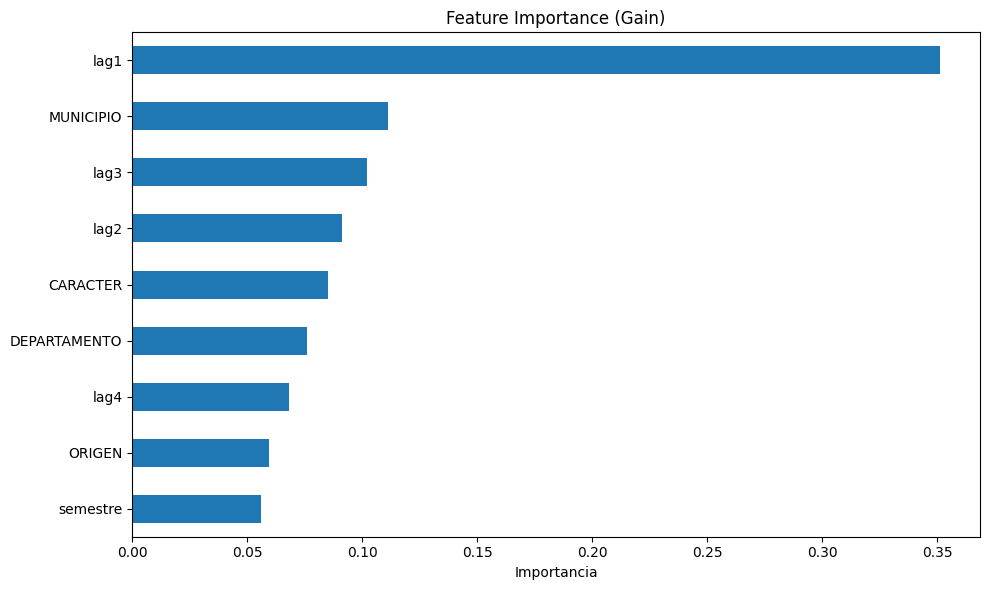

In [12]:
importancias = pd.Series(
    modelo_final.feature_importances_,
    index=x_train.columns
).sort_values(ascending=True)
print(importancias)
importancias.plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance (Gain)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## Persistencia del modelo y trazabilidad

Guardamos el modelo entrenado, los mejores hiperparámetros y las métricas, para poder reusar/auditar el resultado sin re-ejecutar los 100 trials de Optuna (FIX A3).

In [13]:
import json

# FIX A3: persistir el modelo y los hiperparametros para trazabilidad y reuso.
modelo_final.save_model('model_xgb.json')

with open('best_params.json', 'w', encoding='utf-8') as f:
    json.dump(study.best_params, f, indent=2, ensure_ascii=False)

# Metricas honestas (selección por validación; test medido una sola vez; seed=42).
metrics = {
    'protocolo': 'Optuna sobre validacion; test medido una sola vez; semilla=42',
    'validacion': {'rmse': round(float(m_val[0]), 4), 'mae': round(float(m_val[1]), 4)},
    'test_agregado': {'rmse': round(float(m_test[0]), 4), 'mae': round(float(m_test[1]), 4)},
    'por_horizonte': {
        'h1_2024_1': {
            'modelo_rmse': round(float(r1[0]), 4), 'modelo_mae': round(float(r1[1]), 4),
            'persistencia_rmse': round(float(p1[0]), 4), 'persistencia_mae': round(float(p1[1]), 4)},
        'h2_2024_2_recursivo': {
            'modelo_rmse': round(float(r2r[0]), 4), 'modelo_mae': round(float(r2r[1]), 4),
            'persistencia_rmse': round(float(p2[0]), 4), 'persistencia_mae': round(float(p2[1]), 4)},
    },
    'baselines_test_agregado': {
        'persistencia': {'rmse': round(float(per_test[0]), 4), 'mae': round(float(per_test[1]), 4)},
        'media': {'rmse': round(float(med_test[0]), 4), 'mae': round(float(med_test[1]), 4)},
    },
}
with open('metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print('Artefactos guardados: model_xgb.json, best_params.json, metrics.json')
print(json.dumps(metrics, indent=2, ensure_ascii=False))

Artefactos guardados: model_xgb.json, best_params.json, metrics.json
{
  "protocolo": "Optuna sobre validacion; test medido una sola vez; semilla=42",
  "validacion": {
    "rmse": 4.3578,
    "mae": 2.8075
  },
  "test_agregado": {
    "rmse": 10.1375,
    "mae": 4.3141
  },
  "por_horizonte": {
    "h1_2024_1": {
      "modelo_rmse": 11.1616,
      "modelo_mae": 4.7391,
      "persistencia_rmse": 11.4815,
      "persistencia_mae": 4.974
    },
    "h2_2024_2_recursivo": {
      "modelo_rmse": 10.4869,
      "modelo_mae": 4.7157,
      "persistencia_rmse": 11.1939,
      "persistencia_mae": 4.716
    }
  },
  "baselines_test_agregado": {
    "persistencia": {
      "rmse": 10.0713,
      "mae": 4.4182
    },
    "media": {
      "rmse": 13.5134,
      "mae": 7.5858
    }
  }
}


## Mejoras: interpretabilidad (SHAP), incertidumbre (conformal) y robustez (backtesting)

Tres añadidos para un uso responsable en política pública: **por qué** predice el modelo (SHAP), **cuánta incertidumbre** tiene cada predicción (intervalos conformal) y **qué tan estable** es frente a distintos cortes temporales (backtesting rolling-origin).

Importancia global por SHAP (media |valor SHAP|, en puntos de tasa):
lag1            3.050
lag2            0.866
lag4            0.742
MUNICIPIO       0.636
lag3            0.616
CARACTER        0.599
DEPARTAMENTO    0.131
semestre        0.097
ORIGEN          0.015


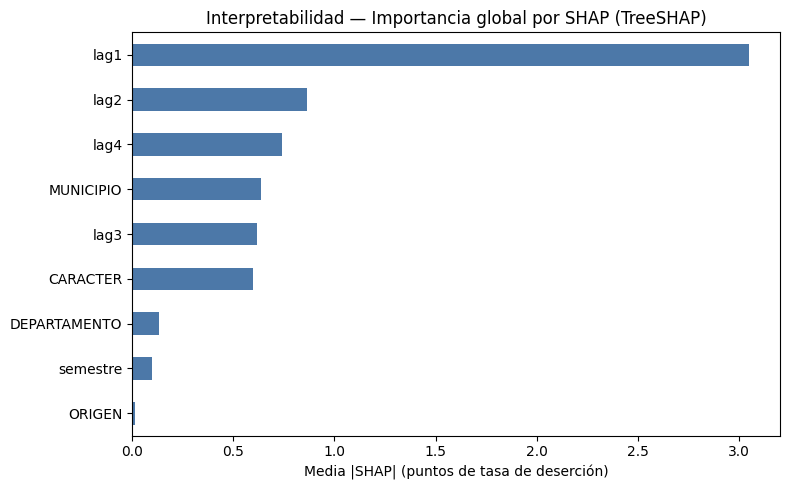

In [14]:
# --- Interpretabilidad: TreeSHAP (valores SHAP exactos de XGBoost via pred_contribs) ---
import xgboost as xgb

booster = modelo_final.get_booster()
dtest_shap = xgb.DMatrix(x_test, enable_categorical=True)
contribs = booster.predict(dtest_shap, pred_contribs=True)   # (n, n_feat+1); ultima col = base
shap_vals = contribs[:, :-1]
shap_imp = pd.Series(np.abs(shap_vals).mean(axis=0),
                     index=x_test.columns).sort_values(ascending=False)
print("Importancia global por SHAP (media |valor SHAP|, en puntos de tasa):")
print(shap_imp.round(3).to_string())

shap_imp.sort_values().plot(kind='barh', figsize=(8, 5), color='#4C78A8')
plt.title('Interpretabilidad — Importancia global por SHAP (TreeSHAP)')
plt.xlabel('Media |SHAP| (puntos de tasa de deserción)')
plt.tight_layout()
plt.show()

In [15]:
# --- Intervalos de prediccion por conformal split (cobertura objetivo 90%) ---
# Calibracion: cuantil 90 de los residuos absolutos en validacion -> banda simetrica.
val_pred = np.clip(modelo_final.predict(x_val), 0, 100)
residuos = np.abs(np.asarray(y_val).ravel() - val_pred)
q = float(np.quantile(residuos, 0.90))

test_pred = np.clip(modelo_final.predict(x_test), 0, 100)
low = np.clip(test_pred - q, 0, 100)
high = np.clip(test_pred + q, 0, 100)
y_test_arr = np.asarray(y_test).ravel()
cobertura = float(np.mean((y_test_arr >= low) & (y_test_arr <= high)))

print(f"Banda conformal (90%): ± {q:.2f} puntos de tasa")
print(f"Cobertura empírica en test: {cobertura*100:.1f}% (objetivo 90%)")
print("Nota: calibrado sobre validación (usada también en early stopping); una calibración")
print("estricta usaría un conjunto de calibración separado. Prueba de concepto de incertidumbre.")

Banda conformal (90%): ± 5.24 puntos de tasa


Cobertura empírica en test: 81.1% (objetivo 90%)
Nota: calibrado sobre validación (usada también en early stopping); una calibración
estricta usaría un conjunto de calibración separado. Prueba de concepto de incertidumbre.


In [16]:
# --- Backtesting rolling-origin: robustez en varios cortes temporales (ML-7) ---
# Re-entrena con los best_params en cada corte y compara contra persistencia.
bp = {k: v for k, v in best_params.items() if k != 'early_stopping_rounds'}
filas_bt = []
for pv in ['2022-1', '2022-2', '2023-1', '2023-2']:
    tr = ds[ds['periodo_target'] < pv]
    va = ds[ds['periodo_target'] == pv]
    if len(tr) == 0 or len(va) == 0:
        continue
    m = XGBRegressor(**bp)
    m.fit(tr[feat], tr['target'])
    p = np.clip(m.predict(va[feat]), 0, 100)
    rmse_m = float(np.sqrt(mean_squared_error(va['target'], p)))
    rmse_p = float(np.sqrt(mean_squared_error(va['target'], np.clip(va['lag1'], 0, 100))))
    filas_bt.append({'corte': pv, 'n': len(va),
                     'modelo_rmse': round(rmse_m, 2), 'persistencia_rmse': round(rmse_p, 2)})

bt = pd.DataFrame(filas_bt)
print(bt.to_string(index=False))
print(f"\nModelo RMSE:       {bt['modelo_rmse'].mean():.2f} ± {bt['modelo_rmse'].std():.2f}")
print(f"Persistencia RMSE: {bt['persistencia_rmse'].mean():.2f} ± {bt['persistencia_rmse'].std():.2f}")

 corte   n  modelo_rmse  persistencia_rmse
2022-1 270         8.58              10.52
2022-2 270         8.04               8.80
2023-1 267         8.32               5.83
2023-2 265         5.15               8.18

Modelo RMSE:       7.52 ± 1.60
Persistencia RMSE: 8.33 ± 1.94
